# 1D static arrays, random numbers and working with files

## Static arrays,
More often than not we need to process a number of variables. That is our program deals not with simple single-valued data, but with a **collection**. The most common type of a collection, throughout different programming languages is an array of data. Arrays can be thought of as continuous containers (for what it is worth in thay are continuous in memory) that store elements one after the other. I like to think about it as a sequence of cups, each storing some 'stuff', arranged one-after-another.  

Arrays can be either **static**, that is such that their size is known before the program is run, and remains fixed throughout the program's lifetime, or **dynamic** that is such that have their size set at *runtime*. We will now have a look at how **static** arrays are handled in **C**. Much of what we show here will be applicable to dynamic arrays.

1. The size of a static array **must be known** at compilation time!    
2. How to create an array, syntax:
    * *type name\[size\]*
    * again: *size* **must** be known at compilation
3. While VLA are allowed in C99 standard, this construct is **forbidden** in this class. As in you will fail on a test if you use it.

### 1. Declaring a 1D array
So to make the long story short. To declare an array of 10 ints, you do:

In [ ]:
int tab[10]; // od 0 do 9
double aaa[60];

But if you do:

In [ ]:
int n=10;
...
int tab[n];

You will get exactly **ZERO** (as in 0!) points on a test. You have been warned!

Let us have a complete program, that does nothing, but declares an array of 10 integers:

In [ ]:
int main()
{
    int tab[10]; //an array of 10 integers, i.e. 40B
}

### 2. Accesing elements with square brackets \[ \]
   * Indexing starts with 0 and is up to size-1
   * Accessing elements outside an array will (or not but do not count on that) cause a **run time** error:

In [ ]:
#include <stdio.h>

int main()
{
    int tab[3];
    
    tab[0] = 10; // indices start from 0!
    tab[1] = 20;
    tab[2] = 30;
    
    printf("Values are: %d %d %d\n", tab[0], tab[1], tab[2]);
}

And this will cause a *runt-time* error:

In [ ]:
#include <stdio.h>

int main()
{
    int tab[3];
    
    tab[0] = 10; // indices start from 0!
    tab[1] = 20;
    tab[2] = 30;
    
    tab[3] = 40; // can not access element 3 since it is out of bounds
    printf("%d %d %d %d", tab[0], tab[1], tab[2], tab[3]);
}

### 3. How is an array stored in the memory
   * It is stored in a continous block.
   * Elements are separated by the number of bytes equal the size of an array type, i.e. 4B for ints and floats, 8B for doubles.

Let us try to print an address of the first element:

In [ ]:
#include <stdio.h>

int main()
{
    int tab[3];
    
    tab[0] = tab[1] = tab[2] = 0;
    
    printf("%d %d %d\n", tab[0], tab[1], tab[2]);
    
    printf("%p\n%p\n%p\n", &(tab[0]), &tab[1], &tab[2]);
    printf("%p\n%p\n%p\n", tab, tab+1, tab+2);
} // c is 12

We note that addresses (position in memory of tab\[0\] is the same as the same pointed by tab). This indicates that tab may, to some extend be considered as being a pointer!?

### 4. Are arrays pointers?
   * Yes (no), almost.
   * Some consequences of pointer arithmetics.
    
Use a pointer to an `int` to access elements of an array ff `int`'s.

In [ ]:
#include <stdio.h>

int main()
{
    int tab[3];
    int *p;// = &tab[0];
    p = tab;
    
    p[0] = 10;
    p[1] = 20;
    p[2] = 30;
    
    printf("%d %d %d | %d\n", tab[0], tab[1], tab[2], p[2]);
    printf("%p %p %p\n%p", &tab[0], &tab[1], &tab[2], p);
}

It seems that using `[  ]` is equivalent to using a `*` operation on a pointer, and in consequence the following is possible:

In [ ]:
#include <stdio.h>

int main()
{
    int tab[3];
    
    tab[0] = 10;
    tab[1] = 20;
    tab[2] = 30;
    
    printf("%d %d %d\n", tab[0], tab[1], tab[2]);
    printf("%d %d %d\n", *tab, *(tab+1), *(tab+2));
    
    printf("%d %d %d\n", *tab, *(1+tab), *(2+tab));
    printf("%d %d %d\n", 0[tab], 1[tab], 2[tab]); // same as *(tab+1)
}

The fact that arrays in **C** allow for access using `index\[array_name\]` should be treated as a curiosity, and a consequence of pointer arithmetics - never to be used in an actual code, as it makes it difficult to read and understand!

In [ ]:
#include <stdio.h>

int main()
{
    double a = 9.0;
    
    printf("%lf \n", a);
    printf("%p %p\n", &a, &a+1);
    int *p = (int *)&a;
    
    p[0] = 5;
    p[1] = 8;
    
    printf("%d %d\n", p[0], *(p+1));
    printf("%lf \n", a);
}

### 5. Passing arrays as arguments to functions

When passing an array to a function, the function must know the *type* and the size.

Example: Write a program that uses two function, one for initialization an array of **doubles** and another to print its values.

In [ ]:
#include <stdio.h>

// Those here are prototypes of functions
void fillarray(double array[], int size);
void printarray(double *array, int size);

int main()
{
    double tab[500];
    int n = 10;
    
    fillarray(tab, n);
    printarray(tab, n);
    
//     fillarray(&tab[5], n);
//     printarray(tab, n+5);
}

// This fills the array with values from 1 up to size
void fillarray(double aaa[], int size)
{
    for(int i=0; i<size; ++i)
    {
        aaa[i] = i+1;
    }
}

void printarray(double *array, int size)
{
    for(int i=0; i<size; ++i)
    {
        printf("i=%d, x=%lf\n", i, array[i]);
    }
}

### 6. Set a maximum allowable size of an array to be used
* Use preprocessors **#define**
* a good practice is to use a **uniqe** identifier for a **#define** to avoid problems

In [ ]:
#include <stdio.h>
#define MAX_SIZE 50

// Those here are prototypes of functions
void fillarray(double array[], int size);
void printarray(double array[], int size);

int main()
{
    int  array1[MAX_SIZE];
    char array2[MAX_SIZE];
    
    double tab[MAX_SIZE];
    
    int n = 10;
    
    fillarray(tab, n);
    printarray(tab, n);
}

// This fills the array with values from 1 up to size
void fillarray(double array[], int size)
{
    for(int i=0; i<size; ++i)
    {
        array[i] = i+1;
    }
}

void printarray(double array[], int size)
{
    for(int i=0; i<size; ++i)
    {
        printf("i=%d, x=%lf\n", i, array[i]);
    }
}

## Random numbers

### 1. How to generate a random number?

* include **stdlib.h** and use `rand()`
* `rand()` returns a random int from zero up to `RAND_MAX`
    
Generate a random number and print it together with the value of `RAND_MAX`, notice that the result is the same every time you run the code.

In [ ]:
#include <stdio.h>
#include <stdlib.h>

int main()
{
    int a = rand();
    printf("%d, %d\n", a, RAND_MAX);
}

### 2. Are random numbers random?
* Well now, thay are just consecutive elements of a predefined sequence of numbers that mimic randomness.
* `srand()` initializes the random sequence to start at a different position

Use `srand()`, rerun the code and see that values have changed, but are still the same on consecutive reruns.

In [ ]:
#include <stdio.h>
#include <stdlib.h>

int main()
{
    srand(90);
    int a = rand();
    printf("%d, %d", a, RAND_MAX);
}

### 3. Initialize a random sequence with current time
* Specifically, with the number of seconds (int) that passed since time Zero.
* Zero time is 00:00:00 Thursday, 1 January 1970
* Yes, there is nothing before time zero ...
* On systems where time is represented by a 32 bit intiger
    time ends after 2147483647 seconds i.e. 3:14:08 19 January 2038 (similar to the [Year 2000 problem](https://en.wikipedia.org/wiki/Year_2000_problem)),see [Year_2038_problem](https://en.wikipedia.org/wiki/Year_2038_problem).
    * The end of the world is coming!
        
Run the code a couple of times and observe that the values change now.

In [ ]:
#include <stdio.h>
#include <stdlib.h>
#include <time.h>

int main(){
    printf("%ld since January 1 1970\n", time(NULL));
    srand(time(NULL));
    
    int a = rand();
    printf("%d, %d", a, RAND_MAX);
}

### 4. How to generate random doubles in a given range?
* Start with values from zero to 1 and than scale and shift as needed
* or learn formulas by hard ...

Generate random numbers from 0 up to 1:

In [ ]:
#include <stdio.h>
#include <stdlib.h> // this here defines RAND_MAX
#include <time.h>

int main()
{
    srand(time(NULL));
    for(int i=0; i<10; ++i)
    {
        double x = (double)rand()/RAND_MAX;
        printf("x=%lf\n", x);
    }
}

Now modify the program so it returns a value from an arbitrary range:

In [ ]:
#include <stdio.h>
#include <stdlib.h> // this here defines RAND_MAX
#include <time.h>

int main()
{
    srand(time(NULL));
    
    double x_min = -5, x_max = 5;
    for(int i=0; i<10; ++i)
    {
        double x = (double)rand()/RAND_MAX;
        x = x_min + x*(x_max-x_min);
        printf("x=%lf\n", x);
    }
}

In [ ]:
#include <stdio.h>
#include <stdlib.h>
#include <time.h>

int main(){
    srand(time(NULL));
    
    double x_max = 20, x_min = 5; // the range of numbers
    
    double a = rand() / (double)RAND_MAX; // this gives values from zoro to 1
    printf("Scale to (0, 1): \t %lf\n", a);
    //now scale:
    a *= (x_max - x_min);
    printf("Scale to (0, scale): \t %lf\n", a);
    //and shift
    a += x_min;
    printf("Shift by x_min: \t %lf\n", a);
}

## A basic sorting algorithm - the [bubble sort](https://en.wikipedia.org/wiki/Bubble_sort)

The simplest algorithm to perform sort of a sequence of values.
Works by comparing consecutive pairs of elements in a sequence and swapping them such that the larger is moved towards end of the collection. After the first pass the last element is the largest, in the second pass the process is repeated and the second largest element becomes second from the end, and so on. This is illustrated with the below animation:

![](movie.gif)

Or with the use of Hungarian folk dance: [Here](https://www.youtube.com/watch?v=lyZQPjUT5B4&ab_channel=AlgoRythmics) (They do other sorting algorithms as well!)

**Exercise:**
Implement Bubble sort and test it for a sequence of random numbers from 0 to 1

In [ ]:
#include <stdio.h>
#include <stdlib.h>
#include <time.h>
#define MS 100

void init()
{
    srand(time(NULL));
}
void tabfill(double a[], int n);
void print(double a[], int n);
void bubble_sort(double a[], int n);

int main()
{
    init();
    
    int n = 10;
    double tab[MS];
    
    tabfill(tab, n);
    print(tab, n);
    bubble_sort(tab, n);
    print(tab, n);
}

//fill an array with values from 0 up to 1
void tabfill(double a[], int n)
{
    for(int i=0; i<n; ++i)
    {
        a[i] = (double)rand() / RAND_MAX;
    }
}

//print elements of an array
void print(double a[], int n)
{
    for(int i=0; i<n; ++i)
    {
        printf("%lf ", a[i]);
    }
    printf("\n");
}

void bubble_sort(double a[], int n)
{
    double tmp;
    for(int j=0; j<n-1; j++)
    {
        for(int i=0; i<n-1-j; ++i)
        {
            if(a[i]>a[i+1])
            {
                tmp = a[i];
                a[i] = a[i+1];
                a[i+1] = tmp;
            }
        }
    }
}

## Working with files

1. FILE structure handles access and operations on files
    * Create a pointer to FILE and initialize with fopen()
        * fopen() works in different modes (see Lecture 8)

*fopen()* usage: *fopen("path_to_file", "access_mode")*.

In the example the file is opened for writing - in this mode file does not need to exist. Should we try to use *fopen* in *reading* mode without the file there would be an error.

In [ ]:
#include <stdio.h>

int main(){
    FILE *f;
    f = fopen("my_file_to_open", "w");
    
    fclose(f);
}

Inspect your working directory, an empty file *my_file_to_open* should have been created.

You can provide a full or relative path to a file with, but **be careful since you can easily override something important**!

In [ ]:
#include <stdio.h>

int main(){
    FILE *f;
    f = fopen("my_file_to_open", "w");
    // or f = fopen("/absolute_path/my_file_to_open", "w");
    
    fclose(f);
}

2. Writing to file is performed with fprintf()
    * similar to printf()
    * *fprintf(FILE *, "the message")*
    
Print some text to a file and on the screen, compare the results:

In [ ]:
#include <stdio.h>

int main()
{
    FILE *file = fopen("my_file_to_open", "w");
    
    //printing to a file with fprintf
    fprintf(file, "I enjoy \t CS1 \t lectures on Tusday,\nthis is myfavorite class!\n" );
    
    //printing on a screen with printf()
    printf("I enjoy \t CS1 \t lectures on Tusday,\nthis is my favorite class!\n" );
    fclose(file);
}

In [ ]:
#include <stdio.h>

int main(){
    FILE *file = fopen("my_file_to_open", "a");
    
    fprintf(file, "And this is new %lf \n", 3.141592);
    
    fclose(file);
}

3. Reading from a file with `fscanf()`
    * similar to `scanf()`
    * `fscanf(FILE *, "format", type *)`
    
Create a file data.dat and fill it with some integers. Read and print:

In [ ]:
#include <stdio.h>

int main(){
    FILE *file = fopen("samples/data.dat", "r");
    
    double a;
    for(int i=0; i<3; ++i)
    {
        fscanf(file, "%lf", &a);
        printf("%lf ", a);
    }
    
    fclose(file);
}

4. Remembar to clean after yourself, i.e. use fclose()
    * for every *fopen* there needs to be an *fclose*
    * *fclose(FILE *)*

## Examples to be done

#### Example 1:
Generate data to plot $sin(x)$ with $x\in[0,2\pi]$.
* Store data in a file.
* Make the plot using the tool you know and have access to, e.g. Excel.

In [ ]:
//%cflags:-lm
#include <stdio.h>
#include <math.h>
#define PI 4.0*atan(1.0)

int main()
{
    int n;
    //scanf("%d", &n);
    n = 100;
    FILE *f = fopen("samples/sin.dat", "w");
    double h = (2.0*PI - 0) / (n-1);
    double x=0.0;
    double y;
    for(int i=0; i<n; ++i)
    {
        y = sin(x);
        fprintf(f, "%lf, %lf\n", x, y);
        x += h; // x = i*h
    }
    fclose(f);
}

#### Example 2:
Read points from `./samples/points.dat' and test how many are located inside a circle o radius $1$ and the center at $(0,0)$.

In [ ]:
//%cflags:-lm
#include <stdio.h>
#include <math.h>
#define PI 4.0*atan(1.0)

int main(){
    int n, ninside=0;
    FILE *f = fopen("samples/points.dat", "r");
    fscanf(f, "%d", &n);
    printf("n=%d\n", n);
    
    double x, y;
    
    for(int i=0; i<n; ++i)
    {
        //fscanf(f, "%lf %lf", &x, &y);
        fscanf(f, "%lf", &x);
        fscanf(f, "%lf", &y);
        // printf("x=%lf y=%lf\n", x, y);
        if( x*x+y*y < 1 )
            ++ninside;
    }
    printf("ninside=%d\n", ninside);
    
    fclose(f);
}

#### Example 3
Generate $n$ random values in the range $(0,1)$ and store in a file.

In [ ]:
#include <stdio.h>
#include <math.h>
#include <stdlib.h>
#include <time.h>

int main()
{
    srand(time(NULL));
    
    int n;
    //scanf("%d", &n);
    n = 1000;
    
    FILE *f = fopen("samples/random_values.dat", "w");
    fprintf(f, "%d\n", n);
    for(int i=0; i<n; ++i)
    {
        fprintf(f, "%lf\n", (double)rand() / RAND_MAX);
    }
    fclose(f);
}

#### Example 4
Read `random_values.dat` generated in exercise 3. Write a function that calculates the average value. In addition the function should provide the number of elements that are below and above the computed average value.

In [ ]:
#include <stdio.h>
#define N 5000

double avg(double *arr, int n, int *p1, int *p2);

int main(){
    int n;
    FILE *f = fopen("samples/random_values.dat", "r");
    fscanf(f, "%d", &n);
    printf("n=%d\n", n);
    if(n > N)
    {
        printf("To large!\n");
        fclose(f);
        return 1;
    }
    double tab[N];
    
    for(int i=0; i<n; ++i)
    {
        fscanf(f, "%lf", &tab[i]);
        //fscanf(f, "%lf", tab+i);
        //printf("%lf\n", tab[i]);
    }
    
    int a, b;
    double av = avg(tab, n, &a, &b);
    printf("%lf %d %d\n", av, a, b);
    
    fclose(f);
}

// double avg(double arr[], int n, int *p1, int *p2)
double avg(double *arr, int n, int *p1, int *p2)
{
    double a = 0;
    int aavg = 0;
    int bavg = 0;
    for(int i=0; i<n; ++i)
    {
        a += arr[i];
    }
    a /= n;
    for(int i=0; i<n; ++i)
    {
        if(arr[i] > a)
        {
            aavg = aavg + 1;
            //aavg += 1;
            //++aavg;
        }
        if(arr[i] < a)
            ++bavg;
    }
    *p1 = aavg;
    *p2 = bavg;
    return a;
}

### Bonus
The notion of addresses and pointers spans beyond simple variable, data and collections. Functions also have an address! The immediate consequence is that we can print this address. But the more important outcome is that we can store this address as a variable, or pass it to other functions. This allows us to write the code in much modular fashion.

In [1]:
#include <stdio.h>

void fun1(){}
void fun2(int a){}
int fun3(){return 0;}
int fun4(int a){return 0;}

int main()
{
    printf("%p\n", fun1);
    printf("%p\n", fun2);
    printf("%p\n", fun3);
    printf("%p\n", fun4);
}

0x7fe425d97119
0x7fe425d97124
0x7fe425d97132
0x7fe425d97141


Since any given function seems to have an address, we should be able to store this address using a pointer.

In [2]:
#include <stdio.h>

void fun1(){}
void fun2(int a){}
int fun3(){return 0;}
int fun4(int a){return 0;}

int main()
{
    void *p = fun1;
    printf("%p\n", p);
    p = fun2;
    printf("%p\n", p);
    p = fun3;
    printf("%p\n", p);
    p = fun4;
    printf("%p\n", p);
}

0x7fbd17b0a119
0x7fbd17b0a124
0x7fbd17b0a132
0x7fbd17b0a141


Not much, but can we call the function, to which we only hold an address?   
Well, yes, but now we need to tell the compiler what the function is and how to call it, what and ho many arguments to pass. This means that `void *p` will not do anymore. In General we will need to define the pointer so it is compatible with the type of the function and the type and number of the arguments.

In [18]:
#include <stdio.h>

void fun1()
{
    printf("Hello from fun1\n");
}
void fun2(int a)
{
    printf("Hello from fun2, a=%d\n", a);
}
int fun3()
{
    printf("Hello from fun3\n"); return 0;
}
int fun4(int a)
{
    printf("Hello from fun4\n"); return a+5;
}

int main()
{
    void( *p)() = fun1;
    fun1();
    p();
    // p = fun2; // !!!!
    // p(10);
    // p = fun3;
    // p();
    // //int a = p();
    // p = fun4;
    // p(10);
    // //int a = p(10);
}

/tmp/tmpwk6m0ixm.c: In function ‘main’:
/tmp/tmpwk6m0ixm.c:27:7: warning: assignment to ‘void (*)()’ from incompatible pointer type ‘int (*)()’ [-Wincompatible-pointer-types]
   27 |     p = fun3;
      |       ^


Hello from fun1
Hello from fun1


More correct solution is then:

In [17]:
#include <stdio.h>

void fun1()
{
    printf("Hello from fun1\n");
}
void fun2(int a)
{
    printf("Hello from fun2, a=%d\n", a);
}
int fun3()
{
    printf("Hello from fun3\n"); return 0;
}
int fun4(int a)
{
    printf("Hello from fun4\n"); return a+23;
}

int main()
{
    void( *p)() = fun1;
    p();
    
    int( *rfun)(int) = fun4;
    int a = rfun(10);
    printf("a=%d\n", a);
}

Hello from fun1
Hello from fun4
a=33


The benefit of having a function pointer is the ability to write functions that can interact with other functions that share a common interface. We can have functions that accept other functions as arguments, as long as the interface is matched!

In [21]:
//%cflags:-lm
#include <stdio.h>
#include <math.h>

double add(double a, double b)
{
    return a+b;
}
double sub(double a, double b)
{
    return a-b;
}
double mul(double a, double b)
{
    return a*b;
}
double dvi(double a, double b)
{
    //printf("aaaa\n");
    return a/b;
}


void funprinter(double c, double d, double(* fp)(double, double))
{
    printf("This is the function result printer\n");
    
    printf("Function at %p with a=%lf b=%lf produced %lf\n", fp, c, d, fp(c,d));
}

int main()
{
    funprinter(25, 5, add);
    funprinter(25, 5, sub);
    funprinter(25, 5, mul);
    funprinter(25, 5, dvi); // !!
    funprinter(25, 5, pow);
}

This is the function result printer
Function at 0x7f779e4cc159 with a=25.000000 b=5.000000 produced 30.000000
This is the function result printer
Function at 0x7f779e4cc181 with a=25.000000 b=5.000000 produced 20.000000
This is the function result printer
Function at 0x7f779e4cc1a9 with a=25.000000 b=5.000000 produced 125.000000
This is the function result printer
Function at 0x7f779e4cc1d1 with a=25.000000 b=5.000000 produced 5.000000
This is the function result printer
Function at 0x7f779e18ae30 with a=25.000000 b=5.000000 produced 9765625.000000


In [27]:
//%cflags:-lm
#include <stdio.h>
#include <math.h>

double diff(double( *f)(double), double x, double eps)
{
    return (f(x+eps) - f(x)) / eps;
}

double myfun(double x)
{
    return x*x*x + 5.0*x*x - 4*x;
}

int main()
{
    printf("%lf\n", diff(myfun, 0.0, 1e-7));
}

-3.999999


### Example
Design a function to compute the area under a curve (an integral) using the so called rectangular method (method of rectangles).

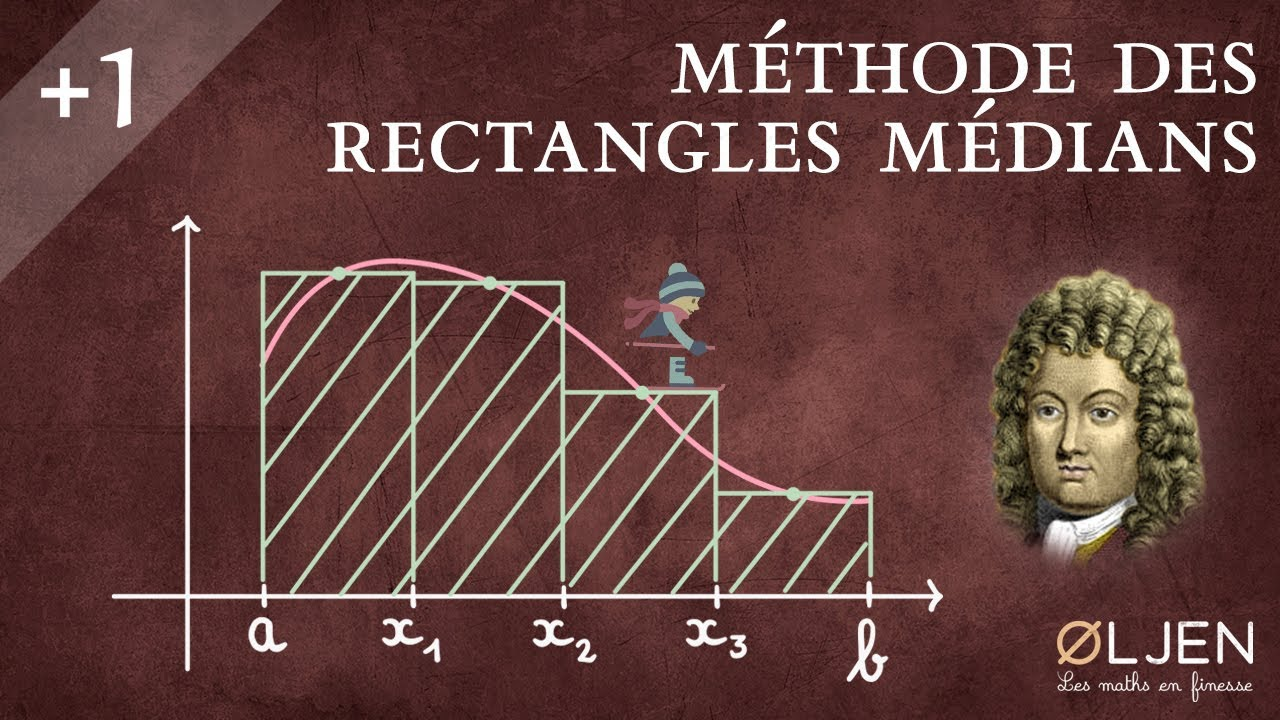

In [40]:
#include <stdio.h>

double integrator(double x0, double x1, double(* fan)(double), int n)
{
    double res = 0;
    double h = (x1 - x0) / n;
    
    for (int i =0; i<n; ++i)
    {
        res += h * fan(h*i + x0);
    }
    return res;
}

double aa(double x)
{
    return 5;
}
double bb(double x)
{
    return 5*x;
}
double cc(double x)
{
    return 5*x*x;
}


int main()
{
    printf("%lf", integrator(0,5, cc, 20));
}

192.968750